In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("/content/Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


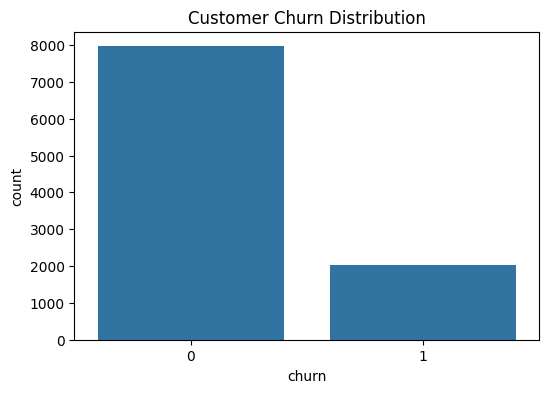

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")
plt.savefig("class_distribution.png")
plt.show()

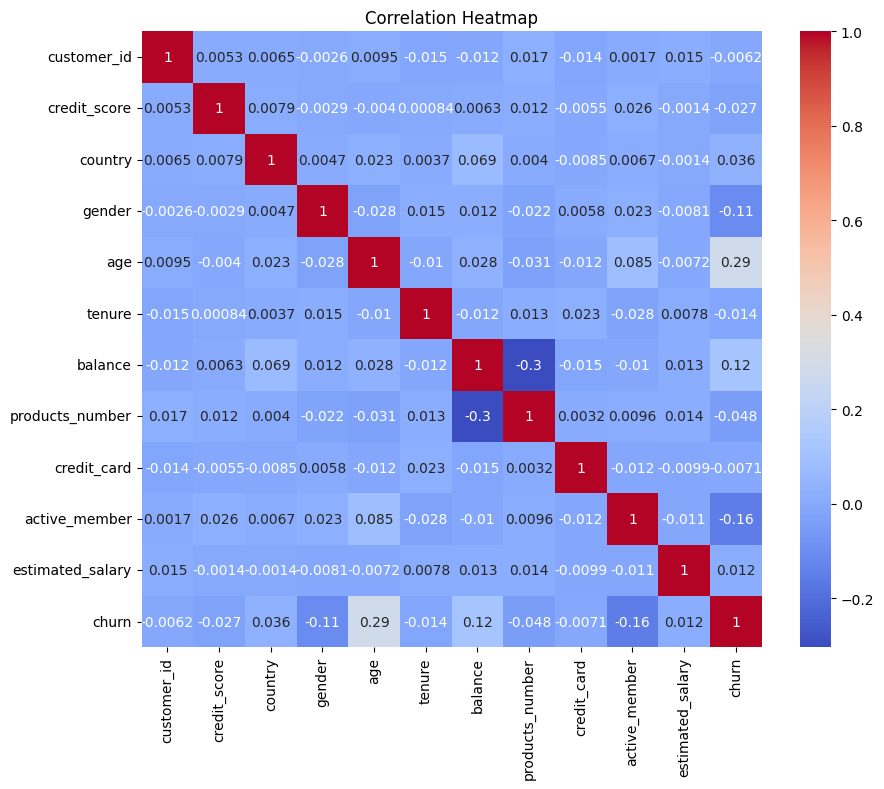

In [6]:
df1=df.copy()

le=LabelEncoder()

df1["country"]=le.fit_transform(df1["country"])
df1["gender"]=le.fit_transform(df1["gender"])

plt.figure(figsize=(10,8))

sns.heatmap(df1.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")

plt.show()

In [7]:
df.drop("customer_id",axis=1,inplace=True)

le=LabelEncoder()

df["country"]=le.fit_transform(df["country"])
df["gender"]=le.fit_transform(df["gender"])

In [8]:
X=df.drop("churn",axis=1)

y=df["churn"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
sc=StandardScaler()

X_train=sc.fit_transform(X_train)

X_test=sc.transform(X_test)

In [10]:
model=RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [11]:
y_pred=model.predict(X_test)

In [12]:
acc=accuracy_score(y_test,y_pred)

print("Accuracy :",acc)

Accuracy : 0.8665


In [13]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.48      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



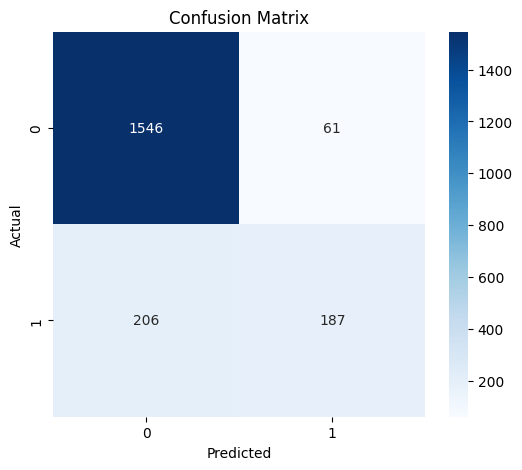

In [14]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

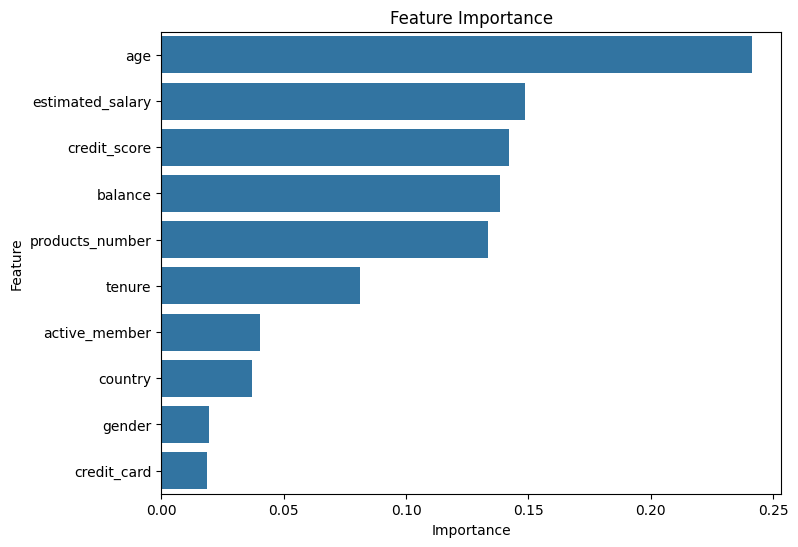

In [15]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.savefig("feature_importance.png")

plt.show()

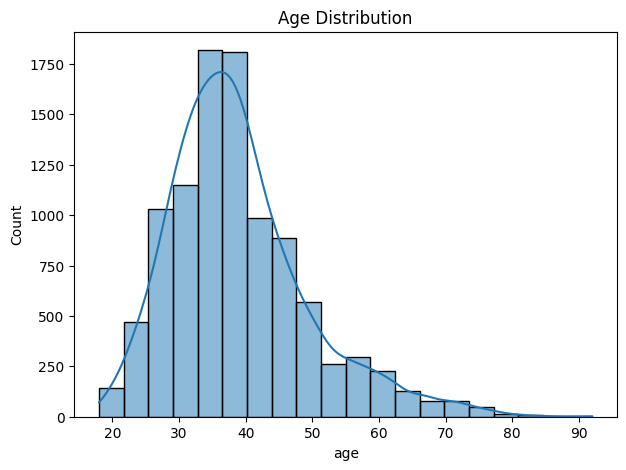

In [16]:
plt.figure(figsize=(7,5))

sns.histplot(df["age"],bins=20,kde=True)

plt.title("Age Distribution")

plt.savefig("age_distribution.png")

plt.show()

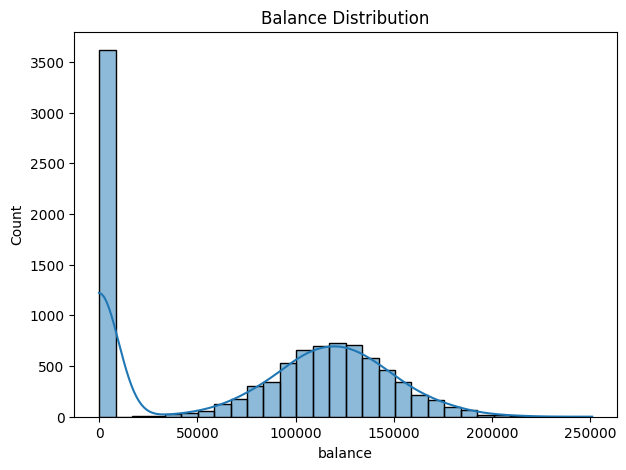

In [17]:
plt.figure(figsize=(7,5))

sns.histplot(df["balance"],bins=30,kde=True)

plt.title("Balance Distribution")

plt.savefig("balance_distribution.png")

plt.show()